<a href="https://colab.research.google.com/github/ykim68ncstate/ST554-homwork_Yujin-Kim/blob/main/HW6/ST554_HW6_YujinKim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST 554 Analysis of BigData - HW5
Name: Yujin Kim

Course: ST 554 (601) Spring 2026 Analysis of Big Data

Assignment: Homework #6

# Part I. More Practice Querying a Database

There is a database file on the assignment link called lahman_1871-2022.sqlite that is an sqlite database [downloaded frome here](https://github.com/jknecht/baseball-archive-sqlite). This database has information on Major League Baseball.

## (1) Connect to the database and then look at all of the tables in the database (use read_sql() from pandas to have this returned as a data frame). (2 pts)

In [176]:
## import libraries and connect to the database file
import sqlite3
import pandas as pd
con = sqlite3.connect("lahman_1871-2022.sqlite")

In [177]:
pd.read_sql("SELECT * FROM sqlite_schema WHERE type = 'table';", con)

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


I use SQL to display all tables available in the SQLite database. This helps me understand the database structure and identify which tables I need for the questions.

## (2) Using SQL, construct a table of hall of fame pitchers (any hall of fame that pitched) that gives the playerID and their total (sum) for GS, G, W, L, IPOuts, CG, SHO, and SV columns. The summing can be done in pandas or in the SQL call. (6 pts)


In [178]:
# Load the pitching table
Pitching = pd.read_sql("SELECT * FROM pitching", con)
Pitching

,playerID,yearID,stint,teamID,lgID,W,L,G,GS,CG,...,IBB,WP,HBP,BK,BFP,GF,R,SH,SF,GIDP
0,aardsda01,2004,1,SFN,NL,1,0,11,0,0,...,0.0,0,2.0,0,61.0,5,8,0.0,1.0,1.0
1,aardsda01,2006,1,CHN,NL,3,0,45,0,0,...,0.0,1,1.0,0,225.0,9,25,1.0,3.0,2.0
2,aardsda01,2007,1,CHA,AL,2,1,25,0,0,...,3.0,2,1.0,0,151.0,7,24,2.0,1.0,1.0
3,aardsda01,2008,1,BOS,AL,4,2,47,0,0,...,2.0,3,5.0,0,228.0,7,32,3.0,2.0,4.0
4,aardsda01,2009,1,SEA,AL,3,6,73,0,0,...,3.0,2,0.0,0,296.0,53,23,2.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50397,zuverge01,1958,1,BAL,AL,2,2,45,0,0,...,3.0,2,6.0,0,294.0,23,29,NaN,NaN,NaN
50398,zuverge01,1959,1,BAL,AL,0,1,6,0,0,...,0.0,1,0.0,0,55.0,1,7,NaN,NaN,NaN
50399,zychto01,2015,1,SEA,AL,0,0,13,1,0,...,0.0,1,2.0,0,76.0,4,6,0.0,0.0,0.0
50400,zychto01,2016,1,SEA,AL,1,0,12,0,0,...,2.0,0,1.0,0,60.0,3,6,0.0,1.0,1.0


I load the full `Pitching` table from the database. This allows me to inspect the pitching data and confirm the avilable columns befor filtering for Hall of Fame pitchers.

In [179]:
# select hall of fame pitchers
hof_pitching = pd.read_sql("""SELECT p.playerID, p.GS, p.G, p.W, p.L, p.IPOuts, p.CG, p.SHO, p.SV FROM pitching p
                          JOIN HallOfFame h ON p.playerID = h.playerID WHERE h.inducted = 'Y';""", con)
hof_pitching

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,alexape01,37,48,28,13,1101,31,7,3
1,alexape01,34,46,19,17,931,25,3,3
2,alexape01,36,47,22,8,919,23,9,2
3,alexape01,39,46,27,15,1065,32,6,1
4,alexape01,42,49,31,10,1129,36,12,3
...,...,...,...,...,...,...,...,...,...
1507,youngcy01,33,36,21,11,897,30,3,2
1508,youngcy01,34,35,19,15,883,30,3,0
1509,youngcy01,20,21,7,10,490,14,1,0
1510,youngcy01,7,7,3,4,139,4,0,0


I use SQL to join the `Pitching` table with the `HallOfFame` table. This returns pitching records only for players who were inducted into the Hall of Fame.

In [180]:
# summarize hall of fame pitching statistics
hof_pitching_sum = hof_pitching.groupby("playerID")[["GS", "G", "W", "L", "IPouts", "CG", "SHO", "SV"]].sum()
hof_pitching_sum

,GS,G,W,L,IPouts,CG,SHO,SV
playerID,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32
ansonca01,0,3,0,1,12,0,0,1
becklja01,1,1,0,1,12,0,0,0
bendech01,334,459,212,127,9051,255,40,34
blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11
wrighge01,0,3,0,1,15,0,0,0
wrighha01,8,36,4,4,301,0,0,14


I group the Hall of Fame pitching data by `playerID` and calculate the total values for the required pitching statistics. This produces one row per pitcher with career totals.

## (3) For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the playerID and their total (sum) for AB, R, H, HR, RBI, BB, and SO. The summing can be done in pandas or in the SQL call. (4 pts)

In [181]:
# load the batting table
batting = pd.read_sql("SELECT * FROM Batting", con)
batting

,playerID,yearID,stint,teamID,lgID,G,G_batting,AB,R,H,...,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,G_old
0,aardsda01,2004,1,SFN,NL,11,None,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,None
1,aardsda01,2006,1,CHN,NL,45,None,2,0,0,...,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.0,None
2,aardsda01,2007,1,CHA,AL,25,None,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,None
3,aardsda01,2008,1,BOS,AL,47,None,1,0,0,...,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0,None
4,aardsda01,2009,1,SEA,AL,73,None,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112179,zwilldu01,1915,1,CHF,FL,150,None,548,65,157,...,24.0,NaN,67,65.0,NaN,2.0,18.0,NaN,NaN,None
112180,zwilldu01,1916,1,CHN,NL,35,None,53,4,6,...,0.0,NaN,4,6.0,NaN,0.0,2.0,NaN,NaN,None
112181,zychto01,2015,1,SEA,AL,13,None,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,None
112182,zychto01,2016,1,SEA,AL,12,None,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,None


I load the ful `Batting` table from the database. This allows me to inspect the batting data before filtering it to Hall of Fame pitchers.

In [182]:
# select hall of fame pitchers' batting records
hof_batting = pd.read_sql("""SELECT b.playerID, b.AB, b.R, b.H, b.HR, b.RBI, b.BB, b.SO FROM Batting b
                          JOIN HallOfFame h On b.playerID = h.playerID WHERE h.inducted = 'Y';""", con)
hof_batting

,playerID,AB,R,H,HR,RBI,BB,SO
0,aaronha01,468,58,131,13,69.0,28,39.0
1,aaronha01,602,105,189,27,106.0,49,61.0
2,aaronha01,609,106,200,26,92.0,37,54.0
3,aaronha01,615,118,198,44,132.0,57,58.0
4,aaronha01,601,109,196,30,95.0,59,49.0
...,...,...,...,...,...,...,...,...
4779,yountro01,614,101,195,21,103.0,63,71.0
4780,yountro01,587,98,145,17,77.0,78,89.0
4781,yountro01,503,66,131,10,77.0,54,79.0
4782,yountro01,557,71,147,8,77.0,53,81.0


This returns batting records only for players who were inducted into the Hall of Fame and also appeared in the batting table.

In [183]:
# summarize hall of fame batting statistics
hof_batting_sum = hof_batting.groupby("playerID")[["AB", "R", "H", "HR", "RBI", "BB", "SO"]].sum()
hof_batting_sum

,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,
aaronha01,12364,2174,3771,755,2297.0,1402,1383.0
alexape01,1810,154,378,11,163.0,77,276.0
alomaro01,9073,1508,2724,210,1134.0,1032,1140.0
alstowa01,1,0,0,0,0.0,0,1.0
andersp01,477,42,104,0,34.0,42,53.0
...,...,...,...,...,...,...,...
wynnea01,1704,136,365,17,173.0,141,330.0
yastrca01,11988,1816,3419,452,1844.0,1845,1393.0
youngcy01,2960,325,623,18,290.0,81,381.0


I group the Hall of Fame batting data by `playerID` and calcuate the total values for the required batting statistics. This produces one row per player with career batting totals.

## (4) Using pandas join the previous two tables together by pitcher. (If you want, try to do all of this via SQL! Not required though, feel free to use pd.merge() if you’d like) (4 pts)

In [184]:
# merge pitching and batting summaries
merged = pd.merge(left = hof_pitching_sum,
                 right = hof_batting_sum,
                 how = "inner",
                 on = "playerID")
merged

,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
playerID,,,,,,,,,,,,,,,
alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163.0,77,276.0
ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075.0,984,330.0
becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581.0,616,526.0
bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116.0,75,143.0
blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25.0,5,193.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
willivi01,471,513,249,205,11988,388,50,11,1493,107,248,1,84.0,81,199.0
wrighge01,0,3,0,1,15,0,0,0,2873,665,866,11,326.0,68,119.0
wrighha01,8,36,4,4,301,0,0,14,813,183,224,4,113.0,37,14.0


I merge the Hall of Fame pitching summary table and the Hall of Fame batting summary table by `playerID`. This creates one combined table containing both pitching and batting career totals for Hall of Fame pitchers

# Part II. Messing with Classes

## (5) In the previous homework we used a loop to repeatedly do simulations around the estimate of a sample slope. The setup was:

* Recall we assume the following model for SLR:
\\[Y_i = β_0 + β_1x_i + E_i\\]
where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution with mean $0$ and variance $σ^2$. Let’s assume $σ^2 = 1$ for simplicity.

* We can generate data from this model by assuming values for $β_0$, $β_1$, and $n$, along with a sequence
of $x$ values.

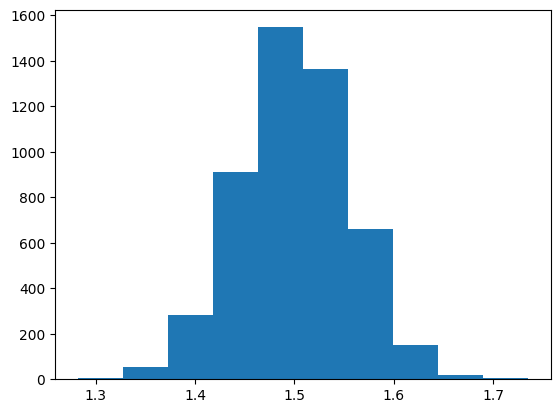

In [185]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object

#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    #find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

In [186]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)

Instead of writing this simulation in this way, we’ll design a Python class that encapsulates the simulation of the sampling distribution of the slope estimator!

Create a class called SLR_slope_simulator:

### a) Initialize the class using __init__ with arguments self, beta_0, beta_1, x, sigma, and seed


* Create initial attributes of beta_0, beta_1, sigma, x, n, rng, and slopes (an empty list)

In [187]:
class SLR_slope_simulator:
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma
        self.x = x
        self.n = len(x) # number of data
        self.rng = default_rng(seed) # save random seed generation
        self.slopes = [] # create empty list for saving result

###b) Required Methods. Your class should include methods (not @classmethod, just methods that work on an already created instances of the class):


* `generate_data` method that generates one dataset (returning $x$ and $y$ in whatever manner you deem fit, i.e. as an array, two arrays, etc.)

In [188]:
    def generate_data(self):
        y = self.beta_0 + self.beta_1 * self.x + self.rng.normal(0, self.sigma, self.n) #self.rng.normal: generate random noise
        return self.x, y

* `fit_slope` method that takes in an $x$ and $y$ and fits the $SLR$ model, returning the estimated slope

In [189]:
    def fit_slope(self, x, y):
        reg = linear_model.LinearRegression() #create LinearRegression() object
        fit = reg.fit(x.reshape(-1,1), y) # x.reshpae: fit() of sklearn only receives 2 dimensions as an input
        return fit.coef_[0] # return slope coefficient

* `run_simulations` method that takes in a number of simulations argument and uses the `generate_data()` and `fit_slope()` methods within a for loop. This should not return anything but should modify the `slopes` attribute (replaces it with an array of slope estimates)

In [190]:
    def run_simulations(self, num_simulations):
        slopes_list = [] #create an empty list for saving results from each simulation

        for i in range(num_simulations): # repeat as much as num_simulation value
            x, y = self.generate_data() # call generate_data method, create a dataset
            slope = self.fit_slope(x, y) # run fit_slope() method, fit simple linear regression, and then return the slope
            slopes_list.append(slope) # append(): add a value at once in the list ;add slope value in end of the list

        self.slopes = np.array(slopes_list) #after all repetition, change the slope value to a numpy array

* `plot_sampling_distribution` method that checks if the `slopes` attribute has length greater than 0 (if it doesn’t print a message that `run_simulations()` must be called first). If it is, it should produce a histogram of the slopes approximating the sampling distribution.

In [191]:
    def plot_sampling_distribution(self):
        if len(self.slopes) == 0: # At the first time, there are no slopes due to self.slopes = []
           print("run_simulations() must be called first")
        else:
           plt.hist(self.slopes)
           plt.xlabel("Estimated slope")
           plt.ylabel("Frequency")
           plt.title("Sampling Distribution of the Slope Estimator")
           plt.show()

* `find_prob` method that takes in a `value` and a `sided` argument. It should checks on the `slopes` attribute as above. If the length is bigger than 0, it should approximate the probability of being “above”, “below”, or “two-sided” (values for `sided`).

  - If `sided` is “above”, you should approximate the probability of being larger than the value.
  - If it is “below”, you should approximate the probability of being smaller than the value.
  - If it is “two-sided”, you should check if the value is above or below the median. If above, you should find two times the probability of being larger, if below, you should find two times the probability of being smaller.

In [192]:
    def find_prob(self, value, sided):
        if len(self.slopes) ==0:
            print("run_simulations() must be called first")
            return None

        if sided == "above": # If sided is “above”
          return np.mean(self.slopes > value) # the probability of being larger than the value.

        elif sided == "below": #If it is “below”
          return np.mean(self.slopes < value) # the probability of being smaller than the value.

        elif sided == "two-sided": #If it is “two-sided”
          median_value = np.median(self.slopes) # check if the value is above or below the median. so set the median_value

          if value > median_value:   #If above
              return 2 * np.mean(self.slopes > value) #two times the probability of being larger
          else: #if below
              return 2 * np.mean(self.slopes < value) #two times the probability of being smaller.


The find_prob method approximates probabilities using the simulated slope estimates stored in the slope attribute. depending on the value of sided argument, the method calcuates the probability that the slope estimate is above, below or two-sided relative to a given value. If no simulations have been run, the method prints a message indicating that `run_simulations()` must be called first.

###c) Below you definition of your class and its methods, add a section of code that

In [193]:
from SLR_slope_simulator import SLR_slope_simulator # import the class from the previously created .py file

* Creates an instance of the object with `beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3), sigma = 1, and seed = 10`

In [194]:
# write creating object
x = np.array(list(np.linspace(start = 0, stop=10, num = 11))*3) #define x

simulator = SLR_slope_simulator(beta_0 = 12, beta_1 = 2, x = x, sigma = 1, seed = 10)

* Call your `plot_sampling_distribution()` method (this should return the error message)

In [195]:
simulator.plot_sampling_distribution()

run_simulations() must be called first


Here I call the `plot_sampling_distribution()` method before running any simulations. Since the slope attribute is still empty, the method correctly prints a message indicating that `run_simulations()` must be called first.

* Run 10000 simulations

In [196]:
simulator.run_simulations(10000)

* Plot the sampling distribution

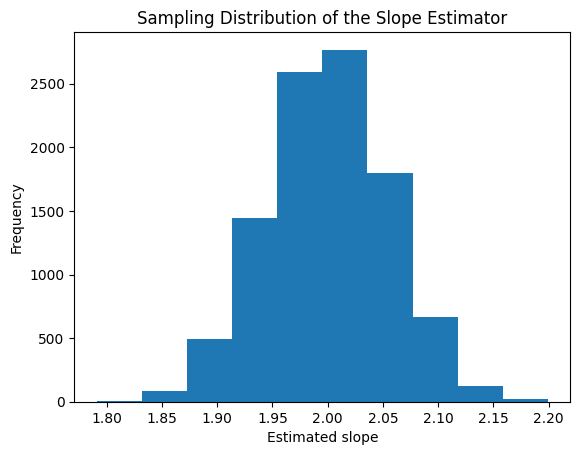

In [197]:
simulator.plot_sampling_distribution()

After running the simulations, I plot the histogram of the estimated slope values stored in the `slopes` attribute, This histogram approximates the sampling distribution of the slope esimator from the simple linear regression model.

* Approximate the two-sided probability of being larger than 2.1

In [198]:
simulator.find_prob(2.1, "two-sided")

np.float64(0.0704)

* Print out the value of the simulated slopes using the attribute

In [199]:
simulator.slopes

array([2.0239168 , 1.99560551, 2.04249093, ..., 1.93451109, 2.01445559,
       2.07173587])

The histogram shows the smapling distribution of the estimated slope values obtained from 10,000 simulated datasets. The distribution is approximately symmetric and centered around 2, which is the true value of the slope used in the data generating process. This indicates that hte slope estimator is approximately unbiased.

The estimated two-sided probability of observing a slope greater than 2.1 in magnitude is approximately 0.0704, suggesting that such extreme slope estimates are relatively unlikely under the assumed model.